# Titanic — Part A: Profiling, Cleaning & the Data Story

Part A of the analytics module: load and profile the raw Titanic dataset, apply a threshold-based missing-value strategy, run univariate and bivariate analysis, build a multivariate "data story," and run an EDA-only standardization sanity check.

**Scope note:** this notebook covers Part A only. The modeling pipeline (with its own train-only scaling, referenced in Task 8) is a separate, later piece of work and is not implemented here.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

## Task 1 — Load & profile the raw dataset

In [2]:
from pathlib import Path

# Detect whether the notebook is being run from the repository root
# or from inside /analytics.
if Path.cwd().name == "analytics":
    ANALYTICS_DIR = Path(".")
else:
    ANALYTICS_DIR = Path("analytics")

ANALYTICS_DIR.mkdir(exist_ok=True)

CSV_PATH = ANALYTICS_DIR / "titanic.csv"

try:
    # The one and only network load of the raw dataset.
    df = sns.load_dataset("titanic")

    # Immediately save the committed offline fallback.
    df.to_csv(CSV_PATH, index=False)

    print(f"Loaded {len(df)} rows from seaborn.")
    print(f"Offline fallback saved to: {CSV_PATH}")

except Exception as err:

    print(f"sns.load_dataset failed: {err}")
    print(f"Loading offline fallback from: {CSV_PATH}")

    df = pd.read_csv(CSV_PATH)

Loaded 891 rows from seaborn.
Offline fallback saved to: analytics/titanic.csv


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.shape

(891, 15)

In [6]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Percentage missing (columns with any missing values):")
print(missing_pct)

Percentage missing (columns with any missing values):
deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
dtype: float64


## Task 2 — Missing-value handling

In [7]:
before_rows = len(df)
df = df.dropna(subset=['embarked', 'embark_town']).reset_index(drop=True)
print(f"embarked/embark_town were missing on the same {before_rows - len(df)} rows -> dropped. "
      f"Rows remaining: {len(df)}")

embarked/embark_town were missing on the same 2 rows -> dropped. Rows remaining: 889


In [8]:
n_missing_age = df['age'].isnull().sum()
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)
print(f"age: imputed {n_missing_age} missing values (19.87% of the original dataset) "
      f"with the column median = {age_median}.")

age: imputed 177 missing values (19.87% of the original dataset) with the column median = 28.0.


In [9]:
n_missing_deck = df['deck'].isnull().sum()
df['deck'] = df['deck'].astype('object').fillna('Missing')
print(f"deck: {n_missing_deck} missing values (77.22% of the original dataset) "
      f"encoded as their own category, 'Missing'.")

deck: 688 missing values (77.22% of the original dataset) encoded as their own category, 'Missing'.


In [10]:
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print("Remaining null counts after cleaning:")
print(remaining_nulls if len(remaining_nulls) else "None - dataset is fully populated.")
print(f"\nFinal cleaned shape: {df.shape}")

Remaining null counts after cleaning:
None - dataset is fully populated.

Final cleaned shape: (889, 15)


## Task 3 — Univariate analysis: `age` and `fare`

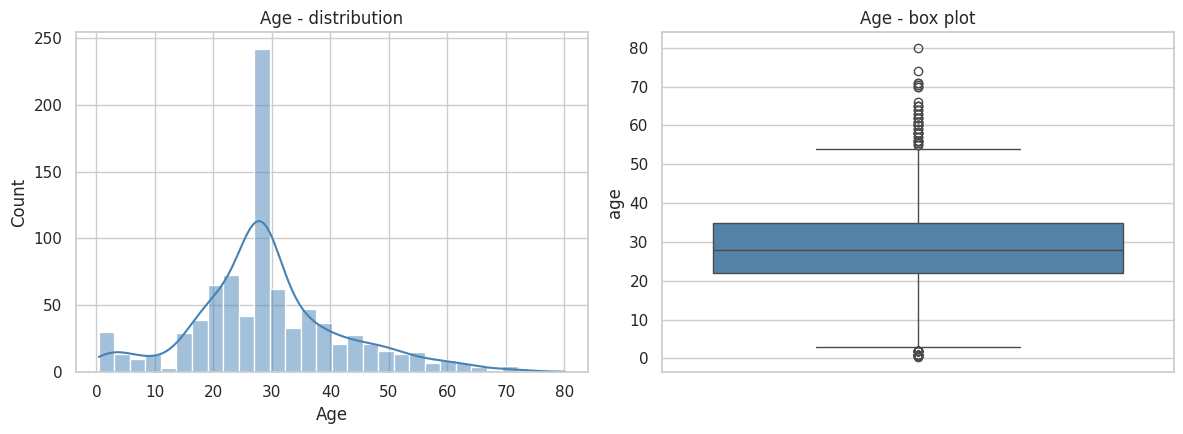

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age - distribution')
axes[0].set_xlabel('Age')

sns.boxplot(y=df['age'], ax=axes[1], color='steelblue')
axes[1].set_title('Age - box plot')
plt.tight_layout()
plt.show()

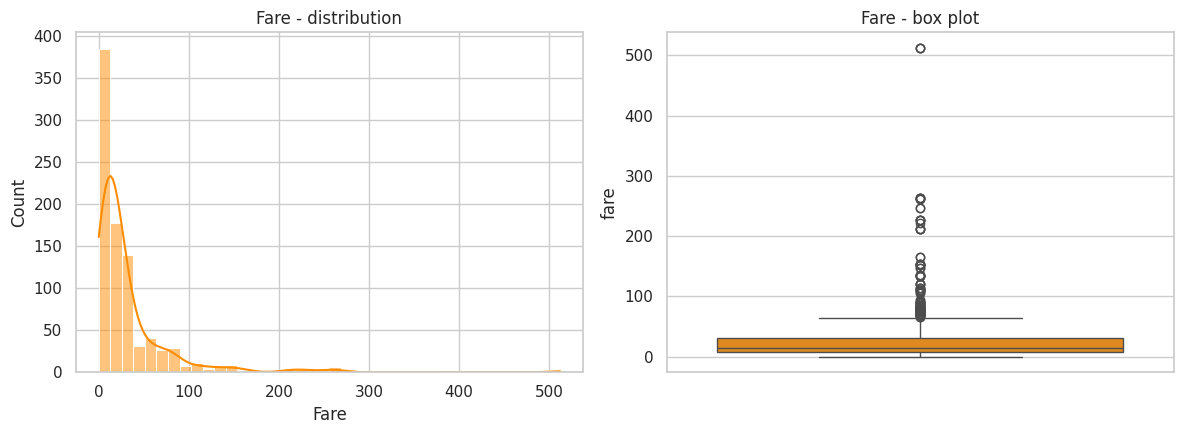

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['fare'], bins=40, kde=True, ax=axes[0], color='darkorange')
axes[0].set_title('Fare - distribution')
axes[0].set_xlabel('Fare')

sns.boxplot(y=df['fare'], ax=axes[1], color='darkorange')
axes[1].set_title('Fare - box plot')
plt.tight_layout()
plt.show()

In [13]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), q1, q3, iqr, lower, upper

for col in ['age', 'fare']:
    n_out, q1, q3, iqr, lower, upper = iqr_outliers(df[col])
    print(f"{col}: Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}  "
          f"bounds=[{lower:.2f}, {upper:.2f}]  -> {n_out} outliers")

age: Q1=22.00  Q3=35.00  IQR=13.00  bounds=[2.50, 54.50]  -> 65 outliers
fare: Q1=7.90  Q3=31.00  IQR=23.10  bounds=[-26.76, 65.66]  -> 114 outliers


In [14]:
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode().iloc[0]
print(f"fare: mean={fare_mean:.2f}  median={fare_median:.2f}  mode={fare_mode:.2f}")

fare: mean=32.10  median=14.45  mode=8.05


## Task 4 — Bivariate analysis

In [15]:
male_mask = df['sex'] == 'male'
female_mask = df['sex'] == 'female'

survival_by_sex = pd.Series({
    'male': df.loc[male_mask, 'survived'].mean(),
    'female': df.loc[female_mask, 'survived'].mean(),
})
print("Survival rate by sex:")
print((survival_by_sex * 100).round(2).astype(str) + '%')

Survival rate by sex:
male      18.89%
female    74.04%
dtype: object


In [16]:
class1_mask = df['pclass'] == 1
class2_mask = df['pclass'] == 2
class3_mask = df['pclass'] == 3

survival_by_class = pd.Series({
    1: df.loc[class1_mask, 'survived'].mean(),
    2: df.loc[class2_mask, 'survived'].mean(),
    3: df.loc[class3_mask, 'survived'].mean(),
})
print("Survival rate by pclass:")
print((survival_by_class * 100).round(2).astype(str) + '%')

Survival rate by pclass:
1    62.62%
2    47.28%
3    24.24%
dtype: object


In [17]:
results = {}
for sex_label, sex_mask in [('male', male_mask), ('female', female_mask)]:
    for pclass_label, pclass_mask in [(1, class1_mask), (2, class2_mask), (3, class3_mask)]:
        combined_mask = sex_mask & pclass_mask   # boolean AND combination
        results[(sex_label, pclass_label)] = df.loc[combined_mask, 'survived'].mean()

survival_by_sex_class = pd.Series(results).unstack().round(4)
print("Survival rate by sex & pclass:")
survival_by_sex_class

Survival rate by sex & pclass:


,1,2,3
female,0.9674,0.9211,0.5000
male,0.3689,0.1574,0.1354


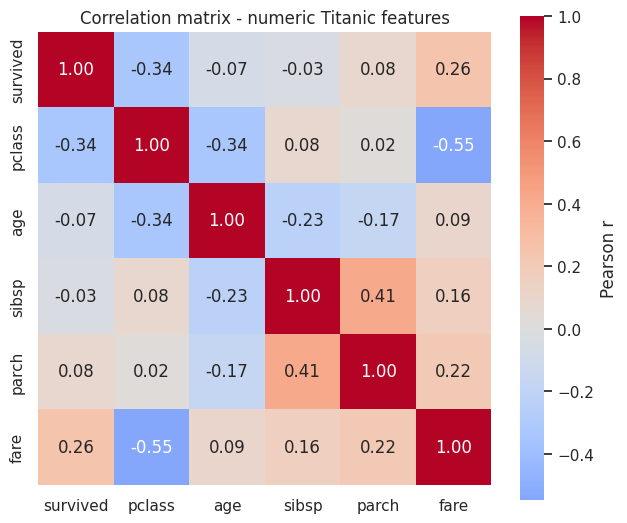

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


In [18]:
cols6 = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = df[cols6].corr()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation matrix - numeric Titanic features')
plt.tight_layout()
plt.show()

corr

In [19]:
pairs = []
for i in range(len(cols6)):
    for j in range(i + 1, len(cols6)):
        pairs.append((cols6[i], cols6[j], corr.iloc[i, j]))

top2 = sorted(pairs, key=lambda p: abs(p[2]), reverse=True)[:2]
for a, b, r in top2:
    print(f"{a} <-> {b}: r = {r:.3f}")

pclass <-> fare: r = -0.548
sibsp <-> parch: r = 0.415


## Task 5 — Multivariate data story: who survived, and why

Five charts build one argument: **survival tracked socioeconomic status and "women and children first" far more than any single trait on its own — and the two interacted.**

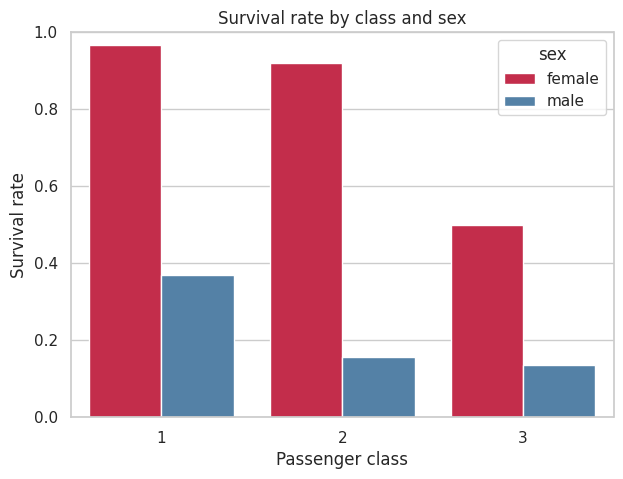

In [20]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='pclass', y='survived', hue='sex', estimator='mean', errorbar=None,
            palette={'male': 'steelblue', 'female': 'crimson'})
plt.ylabel('Survival rate')
plt.xlabel('Passenger class')
plt.title('Survival rate by class and sex')
plt.ylim(0, 1)
plt.show()

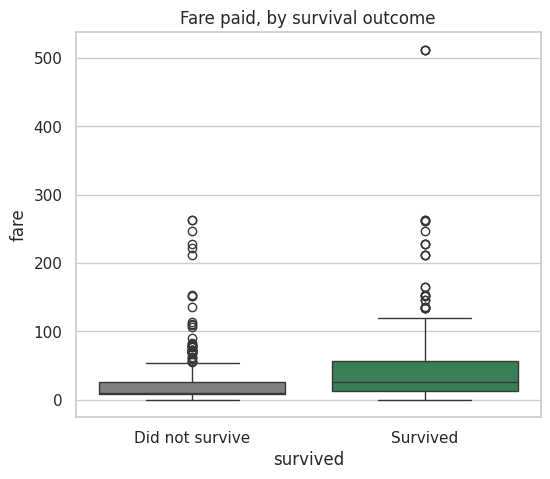

In [21]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='survived', y='fare', hue='survived', palette={0: 'grey', 1: 'seagreen'}, legend=False)
plt.xticks([0, 1], ['Did not survive', 'Survived'])
plt.title('Fare paid, by survival outcome')
plt.show()

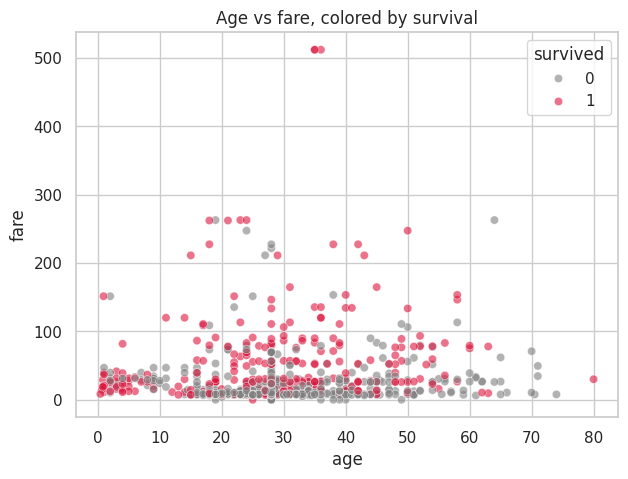

In [22]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='age', y='fare', hue='survived', alpha=0.6,
                 palette={0: 'grey', 1: 'crimson'})
plt.title('Age vs fare, colored by survival')
plt.show()

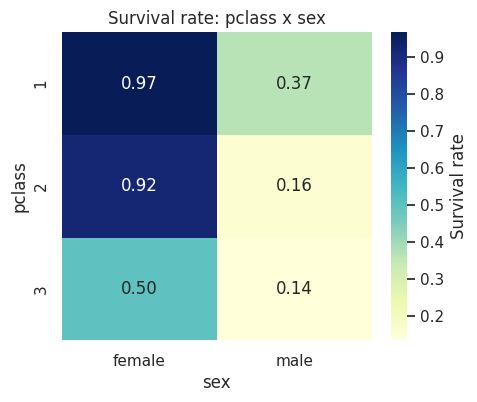

In [23]:
pivot = df.pivot_table(index='pclass', columns='sex', values='survived', aggfunc='mean')
plt.figure(figsize=(5, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Survival rate'})
plt.title('Survival rate: pclass x sex')
plt.show()

This condenses Chart 1 into a single glance: the worst outcome (male, 3rd class, 14%) and the best outcome (female, 1st class, 97%) sit at opposite corners of a fairly smooth gradient — no single cell breaks the pattern of 'female and/or higher class = safer'.

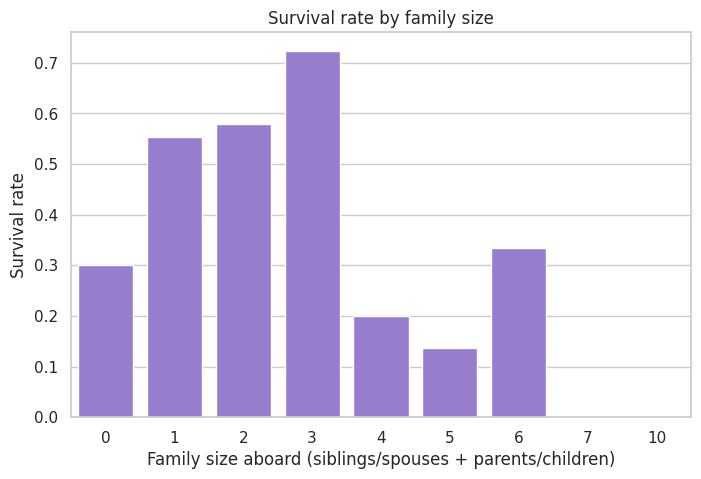

In [24]:
df['family_size'] = df['sibsp'] + df['parch']

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='family_size', y='survived', estimator='mean', errorbar=None,
            color='mediumpurple')
plt.xlabel('Family size aboard (siblings/spouses + parents/children)')
plt.ylabel('Survival rate')
plt.title('Survival rate by family size')
plt.show()

## Task 6 — Standardization check (EDA only)

This is a sanity check on the cleaned `age`/`fare` columns, **not** part of the modeling pipeline — that pipeline fits its own scaler on the training split only, separately.

In [25]:
# StandardScaler scales using population std (ddof=0), so we measure
# "before" and "after" the same way (ddof=0) for a like-for-like comparison.
before = df[['age', 'fare']].agg(['mean', lambda s: s.std(ddof=0)]).round(4)
before.index = ['mean', 'std']
print("Before standardization:")
print(before)

scaler = StandardScaler()
z_scores = scaler.fit_transform(df[['age', 'fare']])
df[['age_zscore', 'fare_zscore']] = z_scores

after = df[['age_zscore', 'fare_zscore']].agg(['mean', lambda s: s.std(ddof=0)]).round(4)
after.index = ['mean', 'std']
print("\nAfter standardization:")
print(after)

Before standardization:
          age     fare
mean  29.3152  32.0967
std   12.9776  49.6695

After standardization:
      age_zscore  fare_zscore
mean         0.0          0.0
std          1.0          1.0


## Summary

Part A is complete: the raw dataset was loaded once (with an offline CSV fallback saved immediately after loading), profiled, cleaned per the stated threshold rule with a justified, percentage-backed decision for every affected column, explored univariately and bivariately (including a 6x6 correlation heatmap), told as a 5-chart survival story, and sanity-checked for standardization. `titanic.csv` — the raw, uncleaned snapshot — ships alongside this notebook as the offline fallback referenced in Task 1.